In [ ]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import healpy as hp

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

wdir = "/n/home07/yitians/fermi/fermi-prob-prog/production"
sys.path.append(f"{wdir}/..")
from models.np_model import NPModel

from matplotlib import pyplot as plt

In [2]:
from dataclasses import dataclass

@dataclass
class Args:
    data: str
    model: str
    n_exp: int
    i: int
    fit_type: str
    n_step: int
    seed: int
    n: int

args = Args(
    data="base23fix_deltapsf",
    model="base23fix_deltapsf",
    n_exp=7,
    i=0,
    fit_type="svi",
    n_step=100,
    seed=4242,
    n=10000,
)

In [3]:
6839 % 7

0

In [14]:
wdir = "/n/home07/yitians/fermi/fermi-prob-prog/production"
run_name = "test"

save_dir = f"{wdir}/../outputs/fit/{run_name}"
os.makedirs(save_dir, exist_ok=True)

mask_roi = np.load(f"{wdir}/mask_roi.npy")
mask_norm = jnp.load(f"{wdir}/mask_norm.npy")

# Ensure mask_roi's length is divisible by args.n_exp
n_pix_remainder = int(np.sum(~mask_roi)) % args.n_exp
if n_pix_remainder != 0:
    unmasked_indices = np.where(mask_roi == 0)[0]
    mask_roi[unmasked_indices[-n_pix_remainder:]] = 1

data = np.load(f"../outputs/sims/{args.data}_n100.npy")[args.i]
if len(data) < hp.nside2npix(128):
    data_full = np.zeros(hp.nside2npix(128))
    data_full[~mask_norm] = data
    data_in = jnp.array(data_full, dtype=jnp.int32)
else:
    data_in = jnp.array(data, dtype=jnp.int32)


psf_tag = 'delta' if 'deltapsf' in args.model else 'king'
print(f'USING PSF {psf_tag}')
m = NPModel(data=data_in, psf_tag=psf_tag, n_exp=args.n_exp, custom_mask_roi=mask_roi)

m.debug_exaggerate_exposure()

USING PSF delta
Number of exposure regions: 7
Number of pixels in ROI: 6839
Using psf: delta
Max photon count is 118


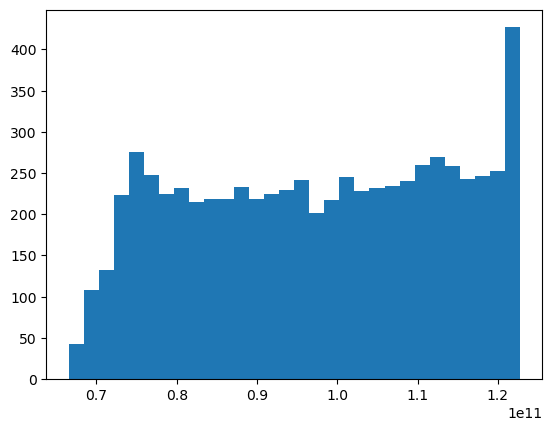

In [10]:
plt.hist(m.exposure_map[~m.mask_roi], bins=30);

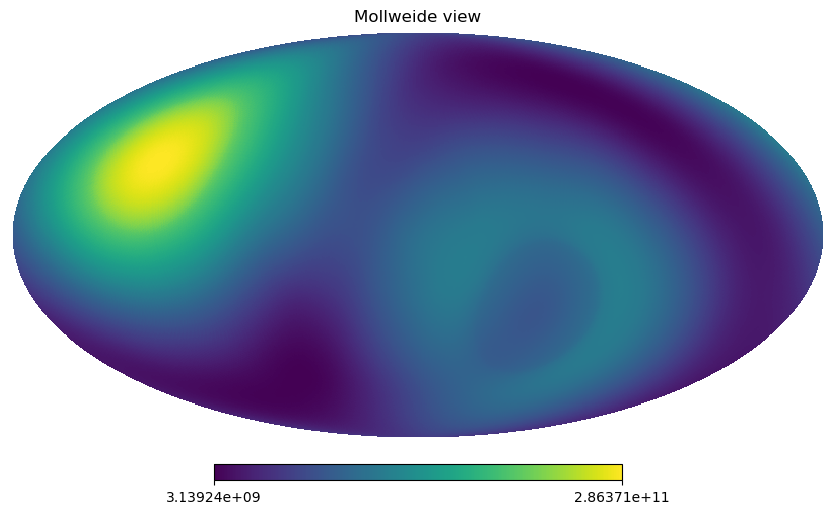

In [11]:
hp.mollview(m.exposure_map)

In [15]:
m.exposure_means_list / m.exposure_mean

Array([0.754749  , 0.83674193, 0.92122175, 1.00449485, 1.08656048,
       1.16198354, 1.23424845], dtype=float64)

In [ ]:
m.expreg_indices[0]

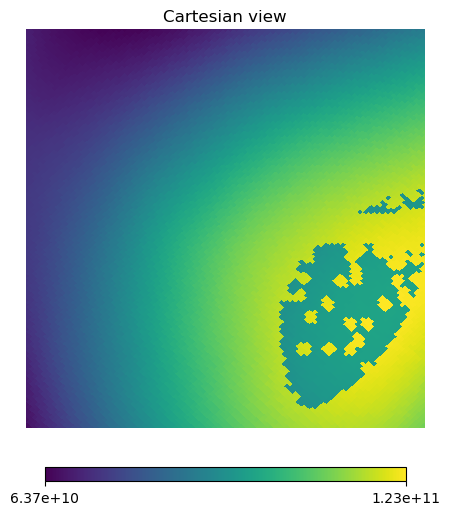

In [12]:
z = np.copy(m.exposure_map)
z[~m.expreg_mask[6]] *= 0.8
hp.cartview(z, lonra=[-25,25], latra=[-25,25])

In [35]:
m.fit_svi(
    n_steps=args.n_step, data=data_in, lr=1e-4,
    rng_key=jax.random.PRNGKey(args.seed)
)
samples = m.get_svi_samples(num_samples=args.n)

100%|██████████| 100/100 [00:56<00:00,  1.78it/s, init loss: 28502.5808, avg. loss [96-100]: 25742.2805]


# flat exposure vs exaggerated exposure

In [23]:
data_fexp = np.load("../outputs/sims/gceps_fexp.npy")
data_x5exp = np.load("../outputs/sims/gceps_x5exp.npy")

/tmp/ipykernel_2914490/282008646.py:10: RuntimeWarning: divide by zero encountered in divide
  hp.cartview(np.mean(data_x5exp, axis=0) / np.mean(data_fexp, axis=0), lonra=[-25,25], latra=[-25,25], hold=True, cmap='coolwarm', min=0.5, max=1.5, title='x5exp / fexp')
/tmp/ipykernel_2914490/282008646.py:10: RuntimeWarning: invalid value encountered in divide
  hp.cartview(np.mean(data_x5exp, axis=0) / np.mean(data_fexp, axis=0), lonra=[-25,25], latra=[-25,25], hold=True, cmap='coolwarm', min=0.5, max=1.5, title='x5exp / fexp')


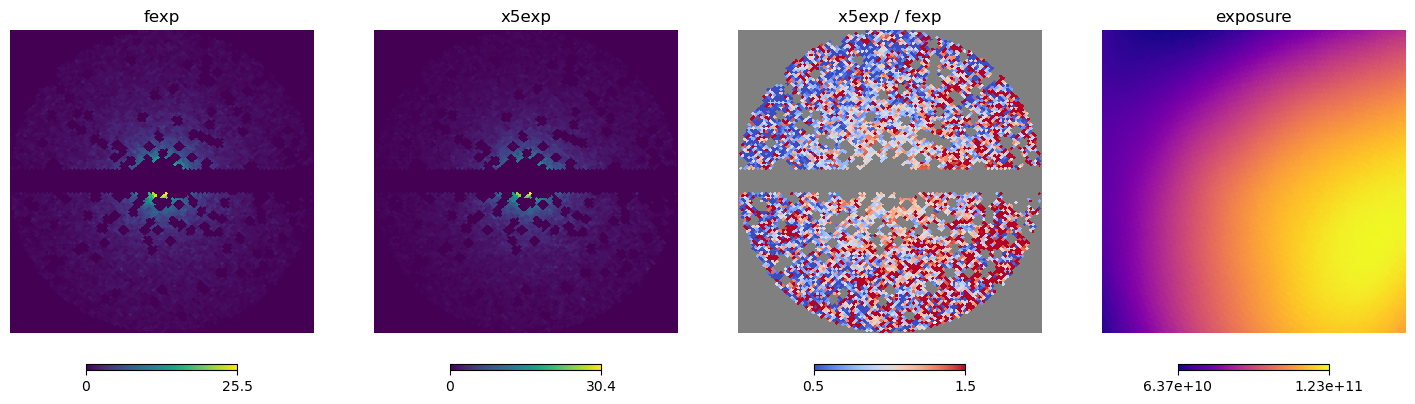

In [26]:
fig, axs = plt.subplots(1, 4, figsize=(18, 5))

plt.sca(axs[0])
hp.cartview(np.mean(data_fexp, axis=0), lonra=[-25,25], latra=[-25,25], hold=True, title='fexp')

plt.sca(axs[1])
hp.cartview(np.mean(data_x5exp, axis=0), lonra=[-25,25], latra=[-25,25], hold=True, title='x5exp')

plt.sca(axs[2])
hp.cartview(np.mean(data_x5exp, axis=0) / np.mean(data_fexp, axis=0), lonra=[-25,25], latra=[-25,25], hold=True, cmap='coolwarm', min=0.5, max=1.5, title='x5exp / fexp')

plt.sca(axs[3])
hp.cartview(m.exposure_map, lonra=[-25,25], latra=[-25,25], hold=True, cmap='plasma', title='exposure')